In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba
import torch
torch.set_grad_enabled(False)

/iridisfs/home/lhl1g23/ssm/mamba


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [2]:
import torch
from omegaconf import OmegaConf
from models.dataloaders.induction_heads import InductionData
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
from models.configs.induction_heads.config import MambaConfig

hps = OmegaConf.load("models/configs/induction_heads/induction_heads.yaml")

data = InductionData(hps.data.batch, hps.data.n_vocab, hps.data.train_len, hps.data.prefix_len)
mambaconfig = MambaConfig()
it = iter(data)

model = MambaLMHeadModel(mambaconfig, device='cuda')
model.load_state_dict(torch.load("/scratch/lhl1g23/mamba/checkpoints/induction_heads.pt", weights_only=True))

/home/lhl1g23/.conda/envs/mamba/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [3]:
model.eval()

batch = next(it)
tokens = batch['tokens'].to('cuda')
X = tokens

out = model(X).logits
pred = out[:,-1,:]

hidden_states = model.backbone.embedding(X)
A, B, C, D, dt, dA, dB, states, y_ssm = model.backbone.layers[0].mixer.get_parameters(hidden_states)

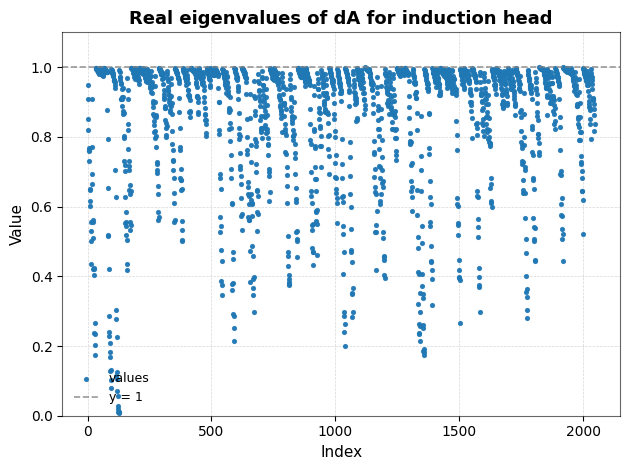

In [5]:
from analyse.utils.plots import plot_eigen, plot_frequency_repsponse_one_step, plot_z_transform_one_step, plot_jacobian_dy_dt, plot_variance, plot_real_eigen

plot_real_eigen(torch.flatten(dA[0, 0, :, :].cpu()).numpy(), title="Real eigenvalues of dA for induction head", s=5)

/tmp/ipykernel_3846397/2952709468.py:15: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  v = torch.var(window_data, dim=0).mean()


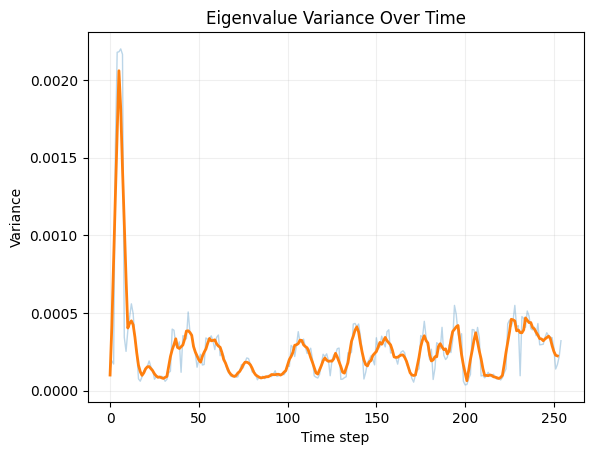

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_variance(M, ax, b_dim, window=100):
    M = M[b_dim]
    l = len(M)

    reshaped = M.reshape(l, -1)
    variances = []

    for t in range(l):
        start = t
        end = min(l, t + window)
        window_data = reshaped[start:end, :]
        v = torch.var(window_data, dim=0).mean()
        variances.append(v)
        

    x = np.arange(len(variances))

    kernel = np.ones(5) / 5
    smooth = np.convolve(variances, kernel, mode="same")

    ax.plot(x, variances, alpha=0.3, linewidth=1)
    ax.plot(x, smooth, linewidth=2)

    ax.set_xlabel("Time step")
    ax.set_ylabel("Variance")
    ax.set_title("Eigenvalue Variance Over Time")

    ax.grid(alpha=0.2)
plot_variance(dA, plt.gca(), 0, window=5)

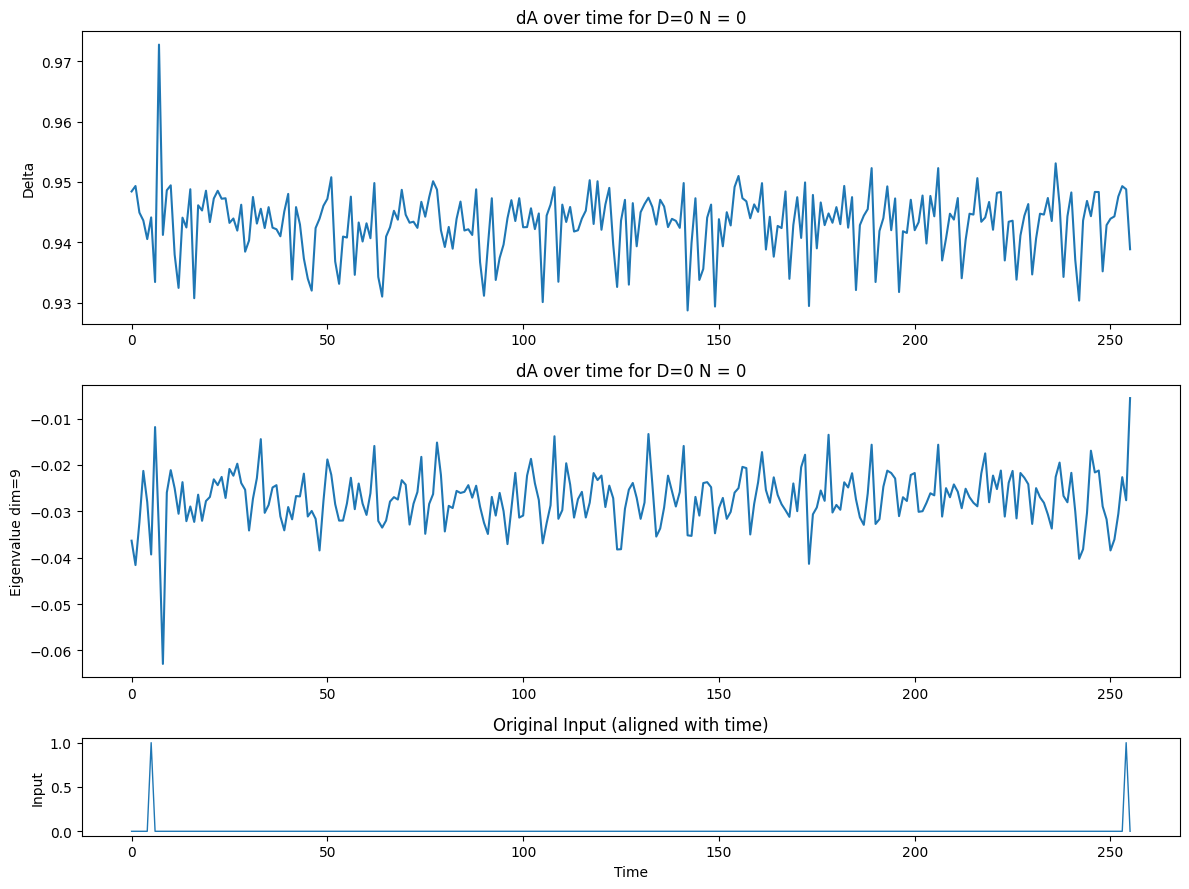

In [19]:
import matplotlib.pyplot as plt
import torch

sample = 0
start = 0
n_din = 128
D, N = 0,0

with torch.no_grad():
    b,l,d,n = dA.shape
    
    fig = plt.figure(figsize=(12,9))
    gs = fig.add_gridspec(3, 1, height_ratios=[3,3,1])
    
    ax0 = fig.add_subplot(gs[0,0])
    ax1 = fig.add_subplot(gs[1,0])
    ax_input = fig.add_subplot(gs[2,0], sharex=ax0)  
    
    #for i in range(start, start + n_din):
    ax0.plot(dA[sample, :, D, N])
    ax0.set_title(f"dA over time for D={D} N = {N}")
    ax0.set_ylabel("Delta")
    
    #for i in range(start, start + n_din):
    ax1.plot(dB[sample, :, D, N])
    ax1.set_title(f"dA over time for D={D} N = {N}")
    ax1.set_ylabel("Eigenvalue dim=9")

    x = (X == 6).int().to('cpu')[sample]
    ax_input.plot(x, linewidth=1.0)
    ax_input.set_title("Original Input (aligned with time)")
    ax_input.set_xlabel("Time")
    ax_input.set_ylabel("Input")
    
    plt.tight_layout()
    plt.show()


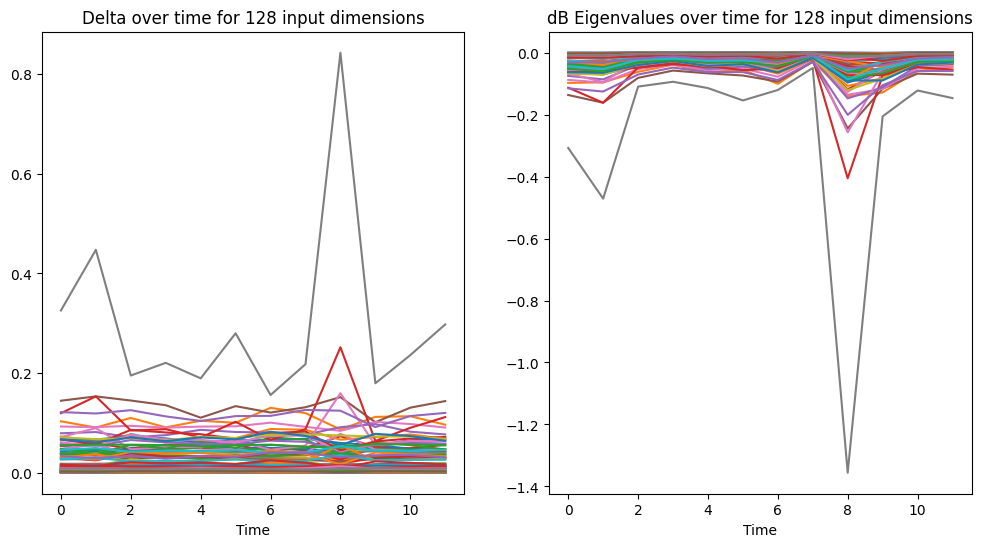

In [7]:
import matplotlib.pyplot as plt

sample = 0

start = 0
n_din = 128
fig, ax = plt.subplots(1,2, figsize=(12,6))

with torch.no_grad():
    b,l,d,n = dA.shape
    for i in range(start, start + n_din):
        y_axis = dt[sample,:,i]
        ax[0].plot(y_axis)
            
    for i in range(start, start + n_din):
        y_axis = dB[sample,:,i,0]
        ax[1].plot(y_axis)

ax[0].set_xlabel("Time")
ax[0].set_title(f"Delta over time for {n_din} input dimensions")
ax[1].set_xlabel("Time")
ax[1].set_title(f"dB Eigenvalues over time for {n_din} input dimensions")
plt.show()

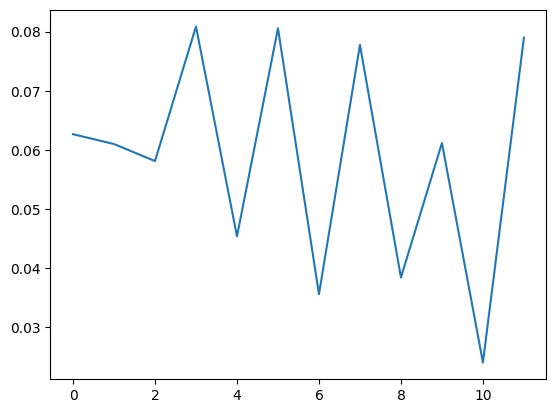

In [8]:
plt.plot(y_ssm[0,:,18])
plt.show()

: 